In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install fastai

from fastai.vision.all import *
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
# Correct path enter karein
path = Path('/content/drive/MyDrive/skindiseasedetection/skindiseasedetection')




In [ ]:
# Load the dataset from the folder and split it into train (80%) and validation (20%)
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,  # Split 80% for training and 20% for validation
    item_tfms=Resize(224),  # Resize images to 224x224
    batch_tfms=aug_transforms(mult=1.0)  # Apply data augmentation
)

# Check the number of training and validation images
print(f"Number of training images: {len(dls.train_ds)}")
print(f"Number of validation images: {len(dls.valid_ds)}")


Number of training images: 6312
Number of validation images: 1578


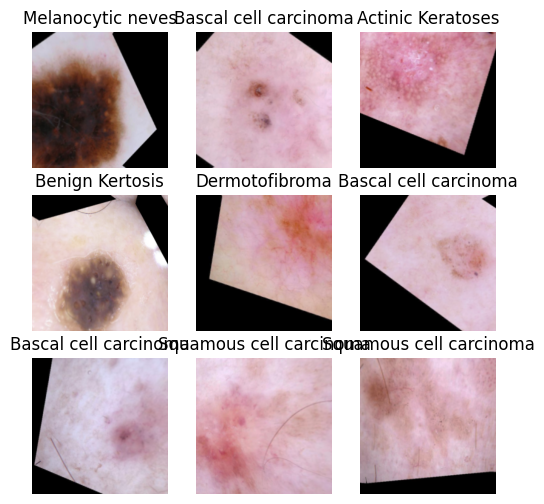

In [ ]:
# Show some samples
dls.show_batch(max_n=9, figsize=(6,6))

In [ ]:
learn = cnn_learner(dls, efficientnet_b0, metrics=accuracy)


/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hu

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

SuggestedLRs(valley=0.0012022644514217973)

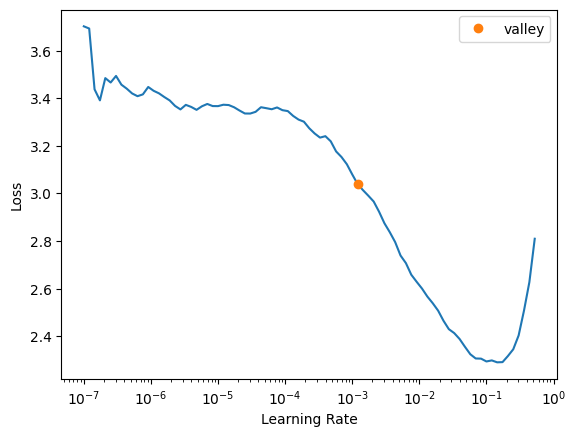

In [ ]:
learn.lr_find()


In [ ]:
learn.fine_tune(10, base_lr=1e-3)  # Best LR ko replace karein


epoch,train_loss,valid_loss,accuracy,time
0,1.597600,0.700352,0.754119,07:50


epoch,train_loss,valid_loss,accuracy,time
0,0.927886,0.581178,0.792776,01:27
1,0.820905,0.436636,0.851077,01:33
2,0.708394,0.367046,0.871356,01:27
3,0.598296,0.284045,0.910646,01:30
4,0.505598,0.251191,0.915716,01:30
5,0.437556,0.232366,0.920152,01:27
6,0.379657,0.210769,0.925856,01:27
7,0.352453,0.204826,0.930925,01:29
8,0.340166,0.192584,0.935995,01:29


epoch,train_loss,valid_loss,accuracy,time
0,0.927886,0.581178,0.792776,01:27
1,0.820905,0.436636,0.851077,01:33
2,0.708394,0.367046,0.871356,01:27
3,0.598296,0.284045,0.910646,01:30
4,0.505598,0.251191,0.915716,01:30
5,0.437556,0.232366,0.920152,01:27
6,0.379657,0.210769,0.925856,01:27
7,0.352453,0.204826,0.930925,01:29
8,0.340166,0.192584,0.935995,01:29
9,0.313762,0.171489,0.941698,01:29


In [ ]:
learn.export('/content/drive/MyDrive/skindiseasedetection/skindisease_model.pkl')
print("Model saved successfully in skindiseasedetection folder!")


Model saved successfully in skindiseasedetection folder!


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

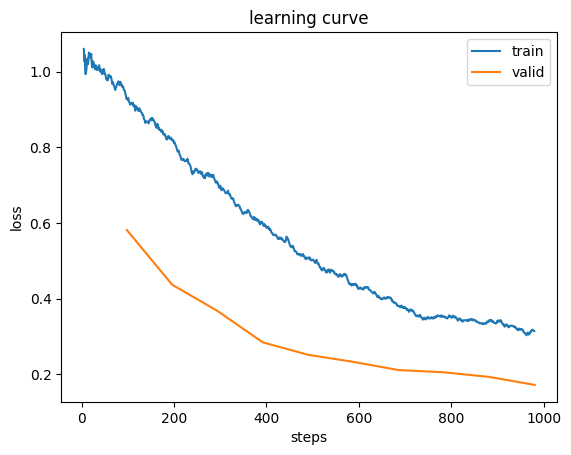

In [ ]:
learn.recorder.plot_loss()


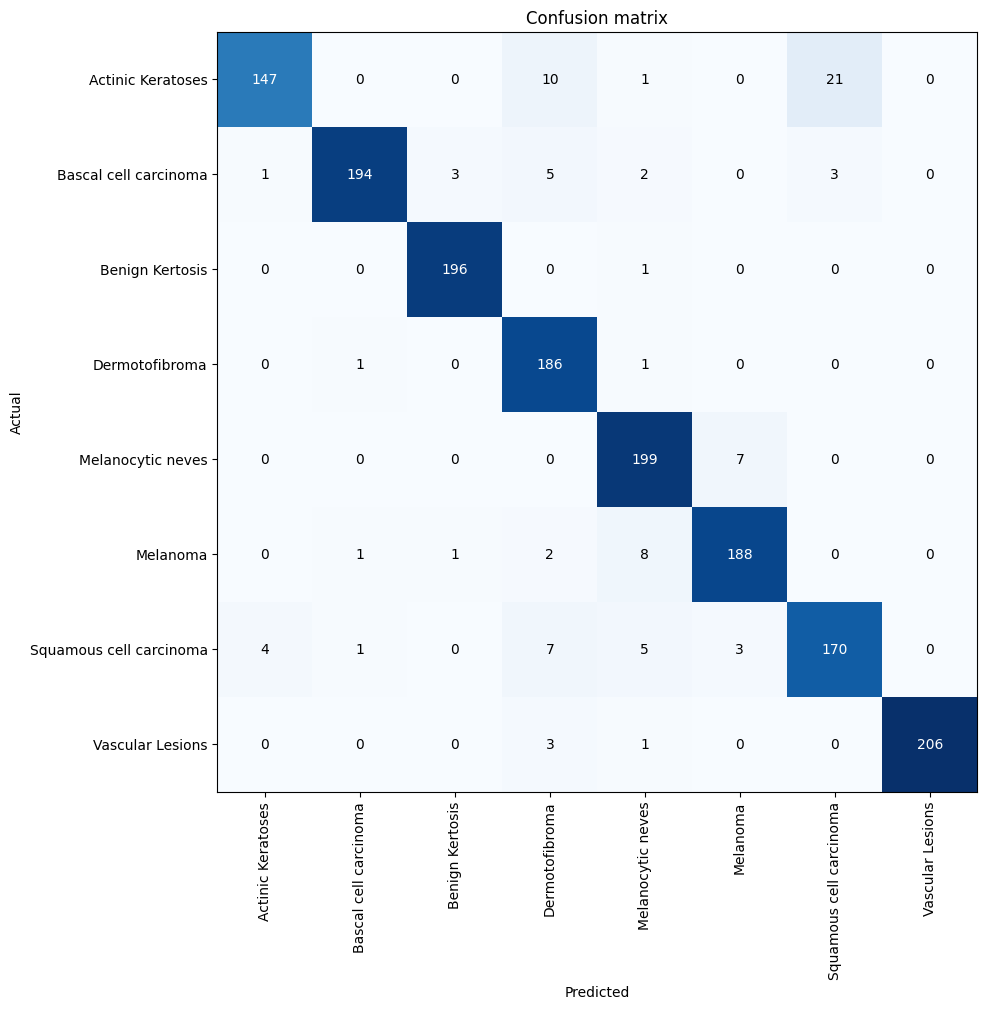

In [ ]:
from fastai.interpret import ClassificationInterpretation

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(10,10))


In [ ]:
print(dls.vocab)  # Check class labels order


['Actinic Keratoses', 'Bascal cell carcinoma', 'Benign Kertosis', 'Dermotofibroma', 'Melanocytic neves', 'Melanoma', 'Squamous cell carcinoma', 'Vascular Lesions']
